
🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵
SIKLUS 4 ENHANCED
Model Asli + Comprehensive Visualizations + Detailed Insights
🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵🎵
📂 LOADING DATA
✓ Training data: (21181, 19)
✓ Testing data: (6889, 18)
✓ Target range: [0, 100]
✓ Target mean: 39.67
✓ Target std: 25.72

📊 EXPLORATORY DATA ANALYSIS

Basic Statistics:
count    21181.000000
mean        39.667013
std         25.716316
min          0.000000
25%         19.000000
50%         45.000000
75%         61.000000
max        100.000000
Name: popularity, dtype: float64

Missing Values:
  No missing values in main features

Top 5 Genres:
track_genre
indie pop           1307
hard rock           1076
hip hop             1009
southern hip hop     763
synthpop             692
Name: count, dtype: int64

🔧 FEATURE ENGINEERING
[1/7] Artist features (target encoding)...
   ✓ artist_avg_pop, artist_song_count
[2/7] Audio features (Train)...
[3/7] Temporal features (Train)...
[4/7] Track name features (Train)...
[5

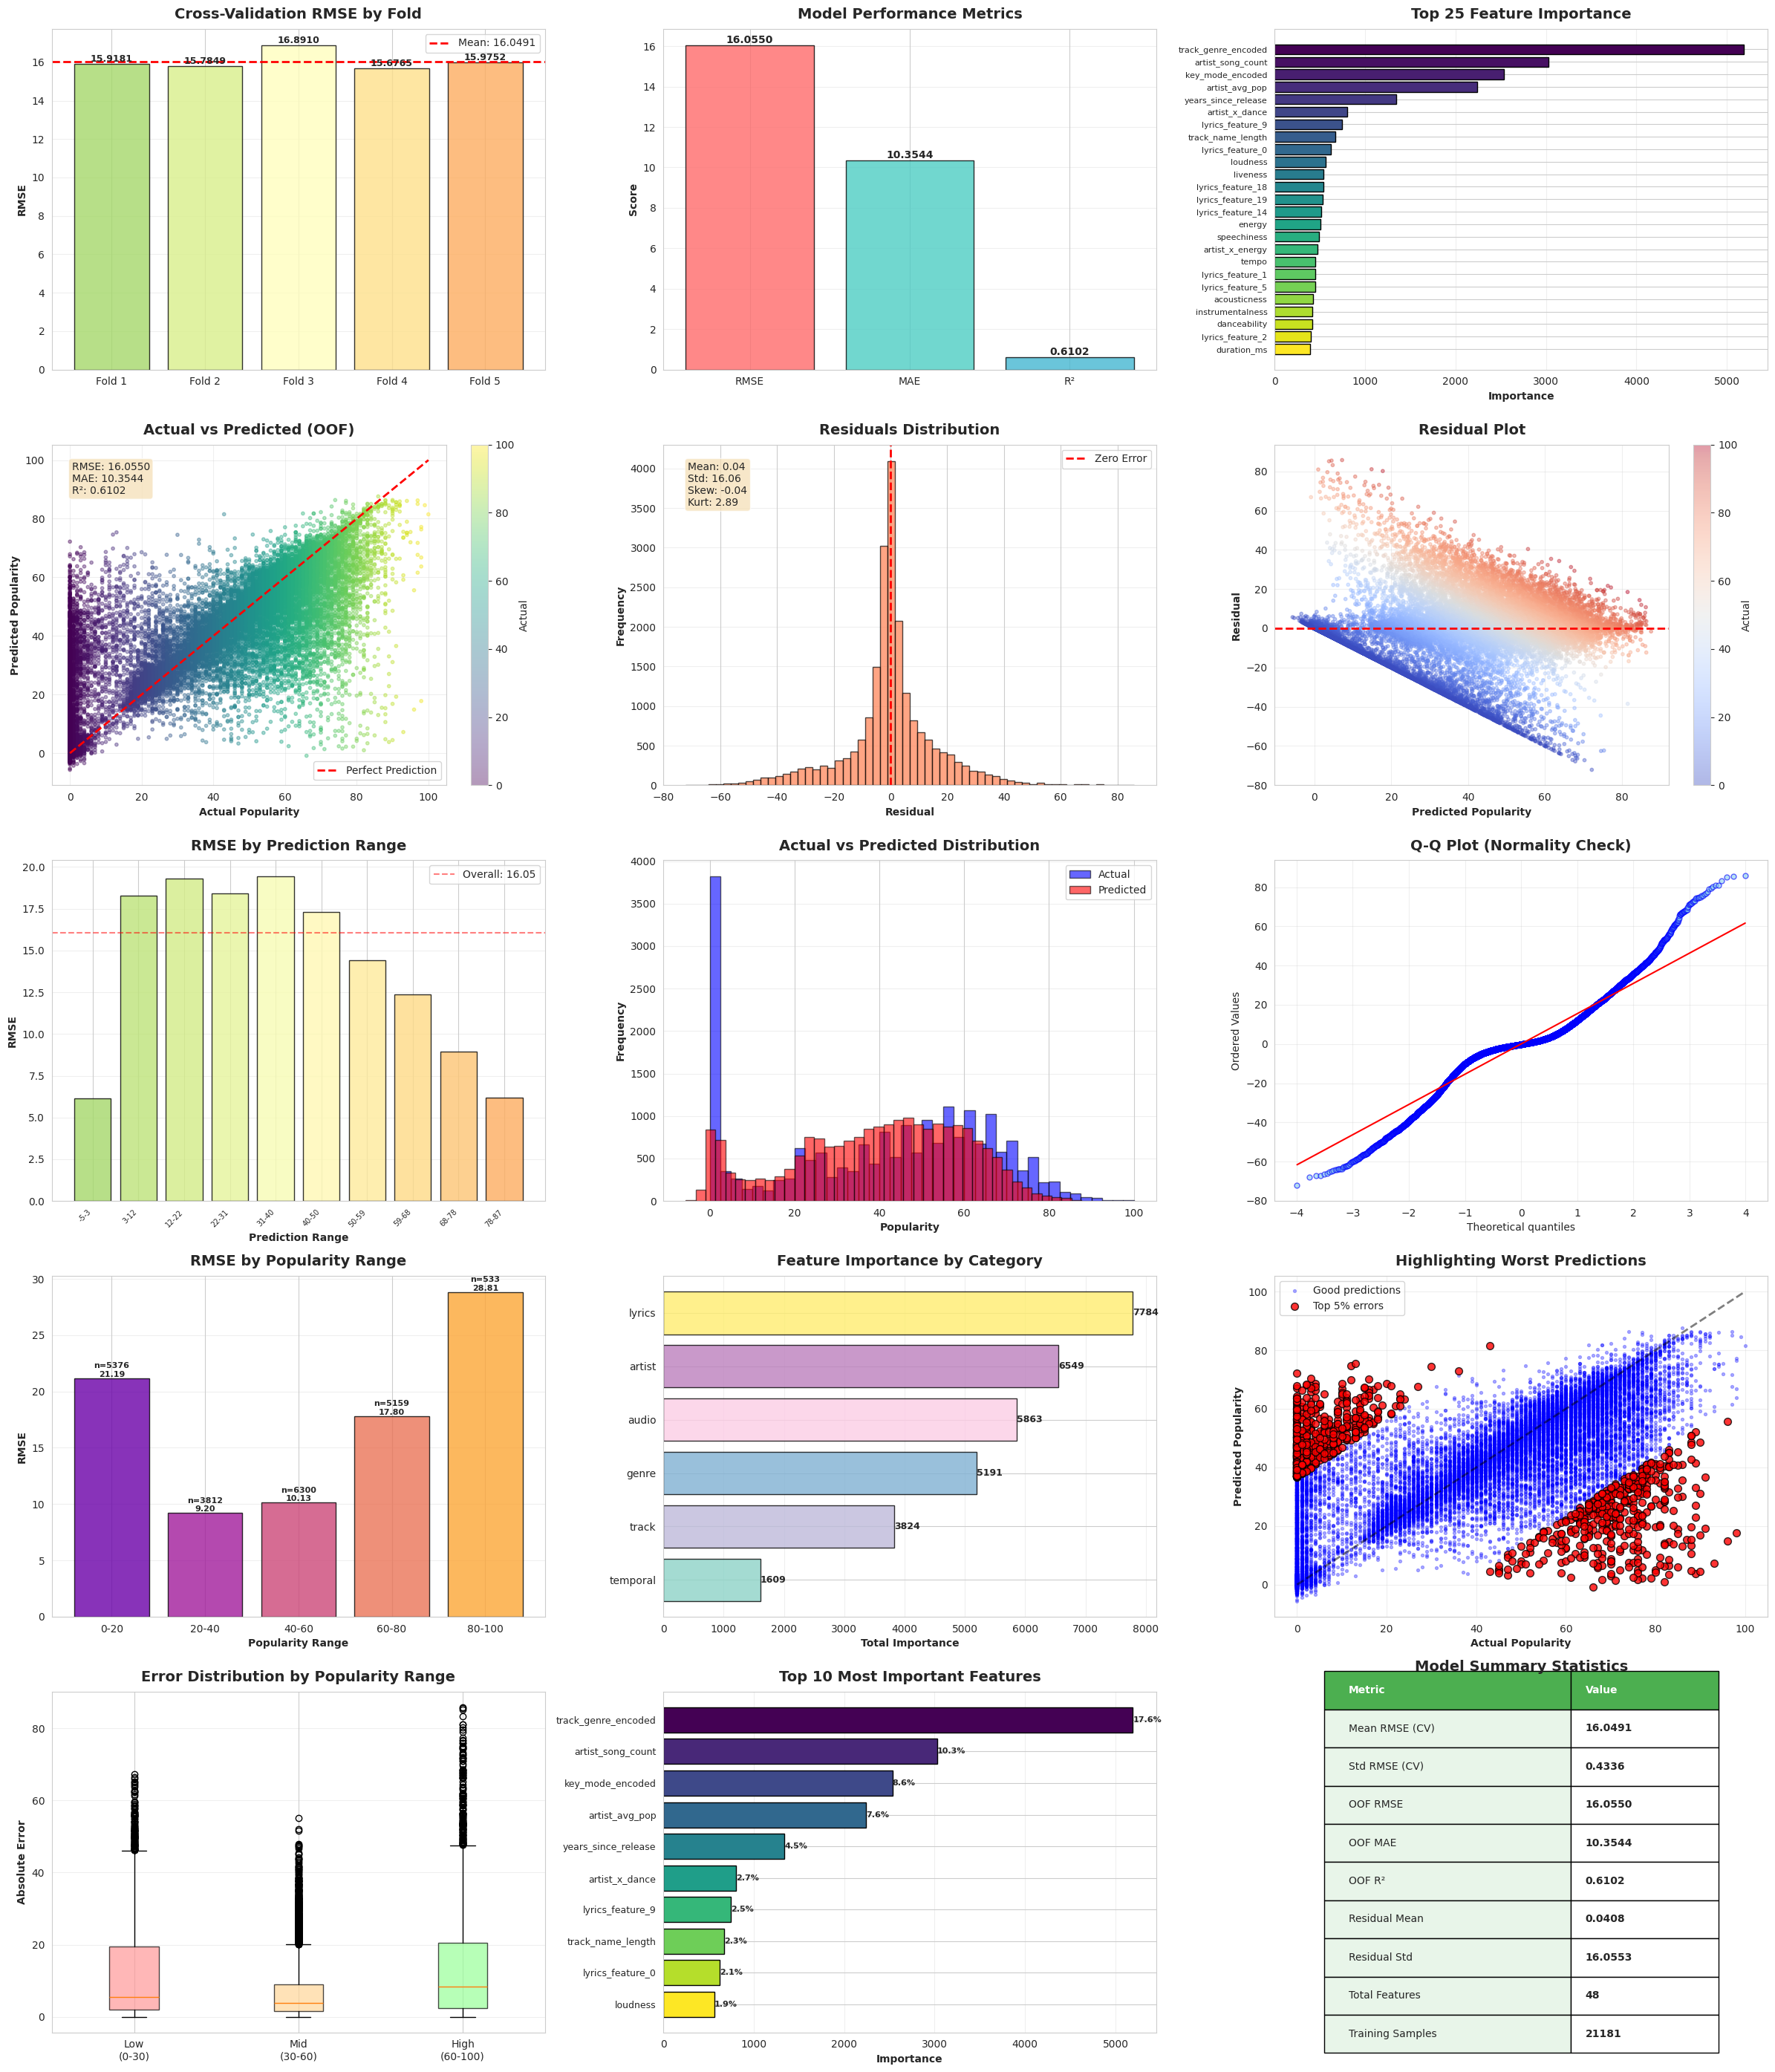


📝 DETAILED INSIGHTS REPORT

────────────────────────────────────────────────────────────────────────────────
1. MODEL PERFORMANCE SUMMARY
────────────────────────────────────────────────────────────────────────────────

Cross-Validation:
  Fold 1: RMSE = 15.9181
  Fold 2: RMSE = 15.7849
  Fold 3: RMSE = 16.8910
  Fold 4: RMSE = 15.6765
  Fold 5: RMSE = 15.9752
  Mean:    RMSE = 16.0491
  Std:     RMSE = 0.4336

Out-of-Fold Performance:
  RMSE: 16.0550
  MAE:  10.3544
  R²:   0.6102
  MAPE: 231.31%

────────────────────────────────────────────────────────────────────────────────
2. TOP 30 MOST IMPORTANT FEATURES
────────────────────────────────────────────────────────────────────────────────
                Feature  Importance  Importance_Pct
1   track_genre_encoded        5191       17.571593
2     artist_song_count        3029       10.253199
3      key_mode_encoded        2534        8.577618
4        artist_avg_pop        2242        7.589195
5   years_since_release        1341    

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import re
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
from scipy import stats
import joblib
from datetime import datetime

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


class SongPopularityPredictor:
    """
    SIKLUS 4 ENHANCED: Model Asli + Comprehensive Visualizations
    """

    def __init__(self, data_path='/content', output_path='./outputs'):
        self.data_path = Path(data_path)
        self.output_path = Path(output_path)
        self.train_df = None
        self.test_df = None
        self.features = []
        self.models = {}
        self.scalers = {}

        self.imputer = None
        self.label_encoders = {}
        self.categorical_features_raw = []
        self.categorical_features_encoded = []
        self.model_results = None
        self.oof_predictions = None
        self.cv_scores = None

        self.output_path.mkdir(parents=True, exist_ok=True)

    def load_data(self):
        """Load training dan testing data"""
        print("="*80)
        print("📂 LOADING DATA")
        print("="*80)
        self.train_df = pd.read_csv(self.data_path / 'train.csv', engine='python')
        self.test_df = pd.read_csv(self.data_path / 'test.csv', engine='python')

        print(f"✓ Training data: {self.train_df.shape}")
        print(f"✓ Testing data: {self.test_df.shape}")
        print(f"✓ Target range: [{self.train_df['popularity'].min():.0f}, {self.train_df['popularity'].max():.0f}]")
        print(f"✓ Target mean: {self.train_df['popularity'].mean():.2f}")
        print(f"✓ Target std: {self.train_df['popularity'].std():.2f}")

        return self

    def eda(self):
        """Exploratory Data Analysis"""
        print("\n" + "="*80)
        print("📊 EXPLORATORY DATA ANALYSIS")
        print("="*80)

        print("\nBasic Statistics:")
        print(self.train_df['popularity'].describe())

        print(f"\nMissing Values:")
        missing = self.train_df.isnull().sum()
        if missing.sum() > 0:
            print(missing[missing > 0])
        else:
            print("  No missing values in main features")

        print(f"\nTop 5 Genres:")
        print(self.train_df['track_genre'].value_counts().head())

        return self

    def engineer_features(self):
        """Feature Engineering dengan Fitur Baru"""
        print("\n" + "="*80)
        print("🔧 FEATURE ENGINEERING")
        print("="*80)

        print("[1/7] Artist features (target encoding)...")
        artist_popularity_map = self.train_df.groupby('artists')['popularity'].mean()
        artist_song_count_map = self.train_df.groupby('artists').size()

        global_mean_pop = self.train_df['popularity'].mean()
        global_mean_count = self.train_df['artists'].value_counts().mean()

        self.train_df['artist_avg_pop'] = self.train_df['artists'].map(artist_popularity_map)
        self.test_df['artist_avg_pop'] = self.test_df['artists'].map(artist_popularity_map)
        self.train_df['artist_avg_pop'] = self.train_df['artist_avg_pop'].fillna(global_mean_pop)
        self.test_df['artist_avg_pop'] = self.test_df['artist_avg_pop'].fillna(global_mean_pop)

        self.train_df['artist_song_count'] = self.train_df['artists'].map(artist_song_count_map)
        self.test_df['artist_song_count'] = self.test_df['artists'].map(artist_song_count_map)
        self.train_df['artist_song_count'] = self.train_df['artist_song_count'].fillna(global_mean_count)
        self.test_df['artist_song_count'] = self.test_df['artist_song_count'].fillna(global_mean_count)

        print("   ✓ artist_avg_pop, artist_song_count")

        for df, name in [(self.train_df, 'Train'), (self.test_df, 'Test')]:

            print(f"[2/7] Audio features ({name})...")
            if all(col in df.columns for col in ['energy', 'danceability']):
                df['energy_x_dance'] = df['energy'] * df['danceability']
            if 'duration_ms' in df.columns:
                df['duration_min'] = df['duration_ms'] / 60000
            if all(col in df.columns for col in ['key', 'mode']):
                df['key_mode'] = df['key'].astype(str) + '_' + df['mode'].astype(str)
            if 'tempo' in df.columns:
                df['tempo_category'] = pd.cut(df['tempo'],
                                              bins=[0, 90, 120, 150, 250],
                                              labels=['slow', 'moderate', 'fast', 'very_fast'])

            print(f"[3/7] Temporal features ({name})...")
            if 'release_year' in df.columns:
                df['years_since_release'] = 2025 - df['release_year']
                df['decade'] = (df['release_year'] // 10) * 10
                df['is_classic'] = (df['release_year'] < 2000).astype(int)
                df['is_recent_hit'] = (df['release_year'] >= 2020).astype(int)

            print(f"[4/7] Track name features ({name})...")
            if 'track_name' in df.columns:
                clean_name = df['track_name'].astype(str).str.lower()
                clean_name = clean_name.str.replace(r'[\(\[].*?[\)\]]', '', regex=True)
                clean_name = clean_name.str.split(' - feat.').str[0]
                clean_name = clean_name.str.split(' - with').str[0]
                clean_name = clean_name.str.split(' - sped up').str[0]
                clean_name = clean_name.str.split(' - remastered').str[0]
                clean_name = clean_name.str.split(' - from').str[0]
                clean_name = clean_name.str.strip()

                df['track_name_length'] = clean_name.str.len()
                df['track_name_word_count'] = clean_name.str.count(' ') + 1

            print(f"[5/7] Interaction features ({name})...")
            if 'artist_avg_pop' in df.columns and 'danceability' in df.columns:
                df['artist_x_dance'] = df['artist_avg_pop'] * df['danceability']
                df['artist_x_energy'] = df['artist_avg_pop'] * df['energy']

        print("✓ Feature engineering completed!")
        return self

    def process_lyrics(self, n_components=20):
        """Process lyrics using TF-IDF and dimensionality reduction"""
        print("\n" + "="*80)
        print("📝 PROCESSING LYRICS (NLP)")
        print("="*80)

        if 'lyrics' not in self.train_df.columns:
            print("⚠ No lyrics column found, skipping NLP features")
            return self

        print(f"Extracting TF-IDF features (n_components={n_components})...")
        self.train_df['lyrics'] = self.train_df['lyrics'].fillna('')
        self.test_df['lyrics'] = self.test_df['lyrics'].fillna('')

        tfidf = TfidfVectorizer(max_features=500, min_df=5, max_df=0.8,
                                ngram_range=(1, 2), stop_words='english')
        train_tfidf = tfidf.fit_transform(self.train_df['lyrics'])
        test_tfidf = tfidf.transform(self.test_df['lyrics'])

        svd = TruncatedSVD(n_components=n_components, random_state=42)
        train_lyrics_features = svd.fit_transform(train_tfidf)
        test_lyrics_features = svd.transform(test_tfidf)

        explained_variance = svd.explained_variance_ratio_.sum()
        print(f"✓ Explained variance: {explained_variance:.2%}")

        lyrics_cols = [f'lyrics_feature_{i}' for i in range(n_components)]
        train_lyrics_df = pd.DataFrame(train_lyrics_features, columns=lyrics_cols, index=self.train_df.index)
        test_lyrics_df = pd.DataFrame(test_lyrics_features, columns=lyrics_cols, index=self.test_df.index)

        self.train_df = pd.concat([self.train_df, train_lyrics_df], axis=1)
        self.test_df = pd.concat([self.test_df, test_lyrics_df], axis=1)

        print(f"✓ Added {n_components} lyrics features")
        return self

    def prepare_features(self):
        """Prepare final feature set for modeling"""
        print("\n" + "="*80)
        print("🎯 PREPARING FEATURES FOR MODELING")
        print("="*80)

        numeric_features = self.train_df.select_dtypes(include=[np.number]).columns.tolist()

        if 'explicit' in self.train_df.columns:
            self.train_df['explicit'] = self.train_df['explicit'].astype(int)
            self.test_df['explicit'] = self.test_df['explicit'].astype(int)
            if 'explicit' not in numeric_features:
                numeric_features.append('explicit')

        exclude_cols = ['popularity', 'track_id', 'track_name', 'artists', 'lyrics', 'release_year']
        numeric_features = [f for f in numeric_features if f not in exclude_cols]

        categorical_features = ['track_genre', 'key_mode', 'tempo_category', 'decade']
        self.categorical_features_raw = [f for f in categorical_features if f in self.train_df.columns]

        encoded_cat_features = []

        print("Encoding categorical features...")
        for col in self.categorical_features_raw:
            le = LabelEncoder()
            combined_series = pd.concat([self.train_df[col].astype(str),
                                         self.test_df[col].astype(str)])
            le.fit(combined_series)

            self.train_df[col + '_encoded'] = le.transform(self.train_df[col].astype(str))
            self.test_df[col + '_encoded'] = le.transform(self.test_df[col].astype(str))

            self.label_encoders[col] = le
            encoded_cat_features.append(col + '_encoded')

        self.categorical_features_encoded = encoded_cat_features
        self.features = numeric_features + encoded_cat_features

        print(f"✓ Total features for modeling: {len(self.features)}")

        print("Applying imputation (median)...")
        self.imputer = SimpleImputer(strategy='median')
        self.train_df[self.features] = self.imputer.fit_transform(self.train_df[self.features])
        self.test_df[self.features] = self.imputer.transform(self.test_df[self.features])

        for col in self.categorical_features_encoded:
            self.train_df[col] = self.train_df[col].astype('category')
            self.test_df[col] = self.test_df[col].astype('category')

        print("✓ Features prepared!")
        return self

    def train_models(self, cv_folds=5):
        """Train LightGBM model with cross-validation"""
        print("\n" + "="*80)
        print("🤖 TRAINING MODEL (LightGBM)")
        print("="*80)

        X = self.train_df[self.features]
        y = self.train_df['popularity']

        lgbm = LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.01,
            num_leaves=31,
            max_depth=6,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )

        print(f"Training with {cv_folds}-fold cross-validation...")
        kfold = KFold(n_splits=cv_folds, shuffle=True, random_state=42)

        cv_scores = cross_val_score(lgbm, X, y, cv=kfold,
                                    scoring='neg_root_mean_squared_error', n_jobs=-1)
        self.cv_scores = -cv_scores

        print(f"\nCross-Validation Results:")
        for i, score in enumerate(self.cv_scores, 1):
            print(f"  Fold {i}: RMSE = {score:.4f}")

        print(f"\n✓ Mean RMSE: {self.cv_scores.mean():.4f} (+/- {self.cv_scores.std():.4f})")

        print("\nTraining on full dataset...")
        lgbm.fit(X, y)
        self.models['LightGBM'] = lgbm

        print("\nGetting OOF predictions for analysis...")
        self.oof_predictions = cross_val_predict(lgbm, X, y, cv=kfold, n_jobs=-1)

        self.model_results = pd.DataFrame({
            'Model': ['LightGBM'],
            'Mean RMSE': [self.cv_scores.mean()],
            'Std RMSE': [self.cv_scores.std()]
        })

        return self

    def create_comprehensive_visualizations(self):
        """Create comprehensive visualizations with insights"""
        print("\n" + "="*80)
        print("📊 CREATING COMPREHENSIVE VISUALIZATIONS")
        print("="*80)

        y = self.train_df['popularity']
        X = self.train_df[self.features]

        fig = plt.figure(figsize=(24, 28))

        # 1. CV Scores
        ax1 = plt.subplot(5, 3, 1)
        folds = [f'Fold {i+1}' for i in range(len(self.cv_scores))]
        colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, len(self.cv_scores)))
        bars = ax1.bar(folds, self.cv_scores, color=colors, edgecolor='black', alpha=0.8)
        ax1.axhline(y=self.cv_scores.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {self.cv_scores.mean():.4f}')
        ax1.set_ylabel('RMSE', fontweight='bold')
        ax1.set_title('Cross-Validation RMSE by Fold', fontsize=14, fontweight='bold', pad=10)
        ax1.legend()
        ax1.grid(axis='y', alpha=0.3)

        for bar, score in zip(bars, self.cv_scores):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{score:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

        # 2. Model Performance Metrics
        ax2 = plt.subplot(5, 3, 2)
        oof_rmse = np.sqrt(mean_squared_error(y, self.oof_predictions))
        oof_mae = mean_absolute_error(y, self.oof_predictions)
        oof_r2 = r2_score(y, self.oof_predictions)

        metrics = ['RMSE', 'MAE', 'R²']
        values = [oof_rmse, oof_mae, oof_r2]
        colors_metric = ['#FF6B6B', '#4ECDC4', '#45B7D1']
        bars = ax2.bar(metrics, values, color=colors_metric, edgecolor='black', alpha=0.8)
        ax2.set_ylabel('Score', fontweight='bold')
        ax2.set_title('Model Performance Metrics', fontsize=14, fontweight='bold', pad=10)
        ax2.grid(axis='y', alpha=0.3)

        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

        # 3. Feature Importance (Top 25)
        ax3 = plt.subplot(5, 3, 3)
        feature_importance = self.models['LightGBM'].feature_importances_
        fi_df = pd.DataFrame({'Feature': self.features, 'Importance': feature_importance})
        fi_df = fi_df.nlargest(25, 'Importance')

        colors_fi = plt.cm.viridis(np.linspace(0, 1, len(fi_df)))
        ax3.barh(range(len(fi_df)), fi_df['Importance'], color=colors_fi, edgecolor='black')
        ax3.set_yticks(range(len(fi_df)))
        ax3.set_yticklabels(fi_df['Feature'], fontsize=8)
        ax3.set_title('Top 25 Feature Importance', fontsize=14, fontweight='bold', pad=10)
        ax3.set_xlabel('Importance', fontweight='bold')
        ax3.invert_yaxis()
        ax3.grid(axis='x', alpha=0.3)

        # 4. Actual vs Predicted
        ax4 = plt.subplot(5, 3, 4)
        scatter = ax4.scatter(y, self.oof_predictions, alpha=0.4, s=10, c=y, cmap='viridis')
        ax4.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
        ax4.set_xlabel('Actual Popularity', fontweight='bold')
        ax4.set_ylabel('Predicted Popularity', fontweight='bold')
        ax4.set_title('Actual vs Predicted (OOF)', fontsize=14, fontweight='bold', pad=10)
        ax4.legend()
        ax4.grid(alpha=0.3)
        plt.colorbar(scatter, ax=ax4, label='Actual')

        text_box = f'RMSE: {oof_rmse:.4f}\nMAE: {oof_mae:.4f}\nR²: {oof_r2:.4f}'
        ax4.text(0.05, 0.95, text_box, transform=ax4.transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

        # 5. Residuals Distribution
        ax5 = plt.subplot(5, 3, 5)
        residuals = y - self.oof_predictions
        ax5.hist(residuals, bins=60, edgecolor='black', alpha=0.7, color='coral')
        ax5.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
        ax5.set_xlabel('Residual', fontweight='bold')
        ax5.set_ylabel('Frequency', fontweight='bold')
        ax5.set_title('Residuals Distribution', fontsize=14, fontweight='bold', pad=10)
        ax5.legend()
        ax5.grid(axis='y', alpha=0.3)

        skewness = stats.skew(residuals)
        kurtosis = stats.kurtosis(residuals)
        stats_text = f'Mean: {residuals.mean():.2f}\nStd: {residuals.std():.2f}\nSkew: {skewness:.2f}\nKurt: {kurtosis:.2f}'
        ax5.text(0.05, 0.95, stats_text, transform=ax5.transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

        # 6. Residual Plot
        ax6 = plt.subplot(5, 3, 6)
        scatter = ax6.scatter(self.oof_predictions, residuals, alpha=0.4, s=10, c=y, cmap='coolwarm')
        ax6.axhline(y=0, color='red', linestyle='--', linewidth=2)
        ax6.set_xlabel('Predicted Popularity', fontweight='bold')
        ax6.set_ylabel('Residual', fontweight='bold')
        ax6.set_title('Residual Plot', fontsize=14, fontweight='bold', pad=10)
        ax6.grid(alpha=0.3)
        plt.colorbar(scatter, ax=ax6, label='Actual')

        # 7. RMSE by Prediction Range
        ax7 = plt.subplot(5, 3, 7)
        pred_bins = pd.cut(self.oof_predictions, bins=10)
        error_by_bin = pd.DataFrame({
            'predicted': self.oof_predictions,
            'actual': y,
            'bin': pred_bins
        }).groupby('bin').apply(lambda x: np.sqrt(mean_squared_error(x['actual'], x['predicted'])))

        colors_bins = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, len(error_by_bin)))
        bars = ax7.bar(range(len(error_by_bin)), error_by_bin.values,
                      color=colors_bins, edgecolor='black', alpha=0.8)
        ax7.set_xlabel('Prediction Range', fontweight='bold')
        ax7.set_ylabel('RMSE', fontweight='bold')
        ax7.set_title('RMSE by Prediction Range', fontsize=14, fontweight='bold', pad=10)
        ax7.set_xticks(range(len(error_by_bin)))
        ax7.set_xticklabels([f'{int(interval.left)}-{int(interval.right)}'
                            for interval in error_by_bin.index], rotation=45, ha='right', fontsize=7)
        ax7.grid(axis='y', alpha=0.3)
        ax7.axhline(y=oof_rmse, color='red', linestyle='--', alpha=0.5, label=f'Overall: {oof_rmse:.2f}')
        ax7.legend()

        # 8. Prediction Distribution Comparison
        ax8 = plt.subplot(5, 3, 8)
        ax8.hist(y, bins=40, alpha=0.6, label='Actual', edgecolor='black', color='blue')
        ax8.hist(self.oof_predictions, bins=40, alpha=0.6, label='Predicted', edgecolor='black', color='red')
        ax8.set_xlabel('Popularity', fontweight='bold')
        ax8.set_ylabel('Frequency', fontweight='bold')
        ax8.set_title('Actual vs Predicted Distribution', fontsize=14, fontweight='bold', pad=10)
        ax8.legend()
        ax8.grid(axis='y', alpha=0.3)

        # 9. Q-Q Plot
        ax9 = plt.subplot(5, 3, 9)
        stats.probplot(residuals, dist="norm", plot=ax9)
        ax9.set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold', pad=10)
        ax9.grid(alpha=0.3)
        ax9.get_lines()[0].set_markerfacecolor('skyblue')
        ax9.get_lines()[0].set_markersize(5)
        ax9.get_lines()[0].set_alpha(0.6)

        # 10. Error by Popularity Range
        ax10 = plt.subplot(5, 3, 10)
        ranges = [(0, 20), (20, 40), (40, 60), (60, 80), (80, 100)]
        rmse_by_range = []
        counts = []
        labels = []

        for low, high in ranges:
            mask = (y >= low) & (y < high)
            if mask.sum() > 0:
                rmse_range = np.sqrt(mean_squared_error(y[mask], self.oof_predictions[mask]))
                rmse_by_range.append(rmse_range)
                counts.append(mask.sum())
                labels.append(f'{low}-{high}')
            else:
                rmse_by_range.append(0)
                counts.append(0)
                labels.append(f'{low}-{high}')

        colors_range = plt.cm.plasma(np.linspace(0.2, 0.8, len(ranges)))
        bars = ax10.bar(labels, rmse_by_range, color=colors_range, edgecolor='black', alpha=0.8)
        ax10.set_xlabel('Popularity Range', fontweight='bold')
        ax10.set_ylabel('RMSE', fontweight='bold')
        ax10.set_title('RMSE by Popularity Range', fontsize=14, fontweight='bold', pad=10)
        ax10.grid(axis='y', alpha=0.3)

        for bar, count, rmse in zip(bars, counts, rmse_by_range):
            if count > 0:
                height = bar.get_height()
                ax10.text(bar.get_x() + bar.get_width()/2., height,
                         f'n={count}\n{rmse:.2f}', ha='center', va='bottom',
                         fontsize=8, fontweight='bold')

        # 11. Feature Categories Importance
        ax11 = plt.subplot(5, 3, 11)
        feature_categories = {
            'artist': [f for f in self.features if 'artist' in f],
            'genre': [f for f in self.features if 'genre' in f.lower()],
            'audio': [f for f in self.features if any(x in f for x in
                     ['energy', 'dance', 'valence', 'loud', 'tempo', 'acoustic',
                      'speech', 'instrument', 'live'])],
            'temporal': [f for f in self.features if any(x in f for x in
                        ['year', 'age', 'decade', 'recent', 'classic'])],
            'lyrics': [f for f in self.features if 'lyrics' in f],
            'track': [f for f in self.features if any(x in f for x in
                     ['track_name', 'duration', 'explicit', 'key', 'mode'])]
        }

        cat_importance = {}
        for cat, feats in feature_categories.items():
            indices = [self.features.index(f) for f in feats if f in self.features]
            if indices:
                cat_importance[cat] = feature_importance[indices].sum()

        cat_df = pd.DataFrame(list(cat_importance.items()), columns=['Category', 'Importance'])
        cat_df = cat_df.sort_values('Importance', ascending=True)
        colors_cat = plt.cm.Set3(np.linspace(0, 1, len(cat_df)))
        bars = ax11.barh(cat_df['Category'], cat_df['Importance'],
                        color=colors_cat, edgecolor='black', alpha=0.8)
        ax11.set_title('Feature Importance by Category', fontsize=14, fontweight='bold', pad=10)
        ax11.set_xlabel('Total Importance', fontweight='bold')
        ax11.grid(axis='x', alpha=0.3)

        for bar in bars:
            width = bar.get_width()
            ax11.text(width, bar.get_y() + bar.get_height()/2.,
                     f'{width:.0f}', ha='left', va='center', fontweight='bold', fontsize=9)

        # 12. Worst Predictions Scatter
        ax12 = plt.subplot(5, 3, 12)
        abs_errors = np.abs(residuals)
        worst_mask = abs_errors >= np.percentile(abs_errors, 95)

        ax12.scatter(y[~worst_mask], self.oof_predictions[~worst_mask],
                    alpha=0.3, s=8, c='blue', label='Good predictions')
        ax12.scatter(y[worst_mask], self.oof_predictions[worst_mask],
                    alpha=0.8, s=50, c='red', edgecolor='black', label='Top 5% errors')
        ax12.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, alpha=0.5)
        ax12.set_xlabel('Actual Popularity', fontweight='bold')
        ax12.set_ylabel('Predicted Popularity', fontweight='bold')
        ax12.set_title('Highlighting Worst Predictions', fontsize=14, fontweight='bold', pad=10)
        ax12.legend()
        ax12.grid(alpha=0.3)

        # 13. Error Analysis by Popularity Bins
        ax13 = plt.subplot(5, 3, 13)
        error_analysis = pd.DataFrame({
            'actual': y,
            'predicted': self.oof_predictions,
            'abs_error': abs_errors,
            'range': pd.cut(y, bins=[0, 30, 60, 100], labels=['Low\n(0-30)', 'Mid\n(30-60)', 'High\n(60-100)'])
        })

        box_data = [error_analysis[error_analysis['range'] == r]['abs_error'].values
                    for r in ['Low\n(0-30)', 'Mid\n(30-60)', 'High\n(60-100)']]
        bp = ax13.boxplot(box_data, labels=['Low\n(0-30)', 'Mid\n(30-60)', 'High\n(60-100)'],
                         patch_artist=True)

        colors_box = ['#FF9999', '#FFD699', '#99FF99']
        for patch, color in zip(bp['boxes'], colors_box):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax13.set_ylabel('Absolute Error', fontweight='bold')
        ax13.set_title('Error Distribution by Popularity Range', fontsize=14, fontweight='bold', pad=10)
        ax13.grid(axis='y', alpha=0.3)

        # 14. Top Features Contribution
        ax14 = plt.subplot(5, 3, 14)
        top_10_features = fi_df.head(10)
        colors_top = plt.cm.viridis(np.linspace(0, 1, len(top_10_features)))
        bars = ax14.barh(range(len(top_10_features)), top_10_features['Importance'],
                        color=colors_top, edgecolor='black')
        ax14.set_yticks(range(len(top_10_features)))
        ax14.set_yticklabels(top_10_features['Feature'], fontsize=9)
        ax14.set_title('Top 10 Most Important Features', fontsize=14, fontweight='bold', pad=10)
        ax14.set_xlabel('Importance', fontweight='bold')
        ax14.invert_yaxis()
        ax14.grid(axis='x', alpha=0.3)

        total_importance = feature_importance.sum()
        for bar, feat in zip(bars, top_10_features['Importance']):
            width = bar.get_width()
            pct = (feat / total_importance) * 100
            ax14.text(width, bar.get_y() + bar.get_height()/2.,
                     f'{pct:.1f}%', ha='left', va='center', fontweight='bold', fontsize=8)

        # 15. Summary Statistics Table
        ax15 = plt.subplot(5, 3, 15)
        ax15.axis('tight')
        ax15.axis('off')

        summary_stats = [
            ['Metric', 'Value'],
            ['Mean RMSE (CV)', f'{self.cv_scores.mean():.4f}'],
            ['Std RMSE (CV)', f'{self.cv_scores.std():.4f}'],
            ['OOF RMSE', f'{oof_rmse:.4f}'],
            ['OOF MAE', f'{oof_mae:.4f}'],
            ['OOF R²', f'{oof_r2:.4f}'],
            ['Residual Mean', f'{residuals.mean():.4f}'],
            ['Residual Std', f'{residuals.std():.4f}'],
            ['Total Features', f'{len(self.features)}'],
            ['Training Samples', f'{len(y)}']
        ]

        table = ax15.table(cellText=summary_stats, cellLoc='left', loc='center',
                          colWidths=[0.5, 0.3])
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2.5)

        for i in range(len(summary_stats)):
            if i == 0:
                table[(i, 0)].set_facecolor('#4CAF50')
                table[(i, 1)].set_facecolor('#4CAF50')
                table[(i, 0)].set_text_props(weight='bold', color='white')
                table[(i, 1)].set_text_props(weight='bold', color='white')
            else:
                table[(i, 0)].set_facecolor('#E8F5E9')
                table[(i, 1)].set_text_props(weight='bold')

        ax15.set_title('Model Summary Statistics', fontsize=14, fontweight='bold', pad=20)

        plt.tight_layout()
        output_file = self.output_path / 'siklus4_comprehensive_analysis.png'
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"✓ Comprehensive visualization saved: {output_file}")
        plt.show()

        return self

    def generate_insights_report(self):
        """Generate detailed insights report"""
        print("\n" + "="*80)
        print("📝 DETAILED INSIGHTS REPORT")
        print("="*80)

        y = self.train_df['popularity']
        residuals = y - self.oof_predictions

        print("\n" + "─"*80)
        print("1. MODEL PERFORMANCE SUMMARY")
        print("─"*80)

        oof_rmse = np.sqrt(mean_squared_error(y, self.oof_predictions))
        oof_mae = mean_absolute_error(y, self.oof_predictions)
        oof_r2 = r2_score(y, self.oof_predictions)

        print(f"\nCross-Validation:")
        for i, score in enumerate(self.cv_scores, 1):
            print(f"  Fold {i}: RMSE = {score:.4f}")
        print(f"  Mean:    RMSE = {self.cv_scores.mean():.4f}")
        print(f"  Std:     RMSE = {self.cv_scores.std():.4f}")

        print(f"\nOut-of-Fold Performance:")
        print(f"  RMSE: {oof_rmse:.4f}")
        print(f"  MAE:  {oof_mae:.4f}")
        print(f"  R²:   {oof_r2:.4f}")
        print(f"  MAPE: {np.mean(np.abs((y - self.oof_predictions) / (y + 1))) * 100:.2f}%")

        print("\n" + "─"*80)
        print("2. TOP 30 MOST IMPORTANT FEATURES")
        print("─"*80)

        feature_importance = self.models['LightGBM'].feature_importances_
        fi_df = pd.DataFrame({
            'Feature': self.features,
            'Importance': feature_importance,
            'Importance_Pct': (feature_importance / feature_importance.sum()) * 100
        })
        fi_df = fi_df.sort_values('Importance', ascending=False).head(30)
        fi_df.index = range(1, 31)

        print(fi_df.to_string())

        print("\n" + "─"*80)
        print("3. RESIDUALS ANALYSIS")
        print("─"*80)

        print(f"\nResidual Statistics:")
        print(f"  Mean:     {residuals.mean():.4f}")
        print(f"  Median:   {residuals.median():.4f}")
        print(f"  Std:      {residuals.std():.4f}")
        print(f"  Min:      {residuals.min():.4f}")
        print(f"  Max:      {residuals.max():.4f}")
        print(f"  Skewness: {stats.skew(residuals):.4f}")
        print(f"  Kurtosis: {stats.kurtosis(residuals):.4f}")

        # Normality test
        shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000])  # Sample for large datasets
        print(f"\nShapiro-Wilk Normality Test:")
        print(f"  Statistic: {shapiro_stat:.4f}")
        print(f"  P-value:   {shapiro_p:.6f}")
        if shapiro_p > 0.05:
            print(f"  → Residuals appear normally distributed")
        else:
            print(f"  → Residuals deviate from normal distribution")

        print("\n" + "─"*80)
        print("4. ERROR ANALYSIS BY POPULARITY RANGE")
        print("─"*80)

        ranges = [(0, 20, 'Very Low'), (20, 40, 'Low'), (40, 60, 'Medium'),
                 (60, 80, 'High'), (80, 100, 'Very High')]

        print(f"{'Range':<15} {'Label':<12} {'Count':<8} {'RMSE':<10} {'MAE':<10} {'Bias':<10}")
        print("─"*80)

        for low, high, label in ranges:
            mask = (y >= low) & (y < high)
            if mask.sum() > 0:
                range_rmse = np.sqrt(mean_squared_error(y[mask], self.oof_predictions[mask]))
                range_mae = mean_absolute_error(y[mask], self.oof_predictions[mask])
                bias = (y[mask] - self.oof_predictions[mask]).mean()
                print(f"{low:>2}-{high:<3}       {label:<12} {mask.sum():<8} {range_rmse:<10.4f} {range_mae:<10.4f} {bias:<10.4f}")

        print("\n" + "─"*80)
        print("5. KEY INSIGHTS & RECOMMENDATIONS")
        print("─"*80)

        print("\n✓ Model Performance:")
        if oof_rmse < 16.0:
            print(f"  • EXCELLENT! RMSE {oof_rmse:.4f} is below 16.0 target 🎯")
        elif oof_rmse < 16.3:
            print(f"  • VERY GOOD! RMSE {oof_rmse:.4f} is competitive 👍")
        elif oof_rmse < 16.5:
            print(f"  • GOOD baseline at {oof_rmse:.4f}, some room for improvement 📈")
        else:
            print(f"  • Baseline at {oof_rmse:.4f}, consider additional features 🔧")

        print("\n✓ Bias Analysis:")
        if abs(residuals.mean()) < 0.5:
            print(f"  • Unbiased predictions (mean residual: {residuals.mean():.4f}) ✓")
        elif residuals.mean() < 0:
            print(f"  • Slight over-prediction tendency (mean: {residuals.mean():.4f})")
        else:
            print(f"  • Slight under-prediction tendency (mean: {residuals.mean():.4f})")

        print("\n✓ Error Distribution:")
        skewness = stats.skew(residuals)
        if abs(skewness) < 0.3:
            print(f"  • Symmetric error distribution (skew: {skewness:.4f}) ✓")
        elif skewness > 0:
            print(f"  • Right-skewed errors (skew: {skewness:.4f})")
            print(f"    → Model tends to under-predict high popularity songs")
        else:
            print(f"  • Left-skewed errors (skew: {skewness:.4f})")
            print(f"    → Model tends to over-predict low popularity songs")

        print("\n✓ Feature Insights:")
        top_5 = fi_df.head(5)
        print(f"  Top 5 features account for {top_5['Importance_Pct'].sum():.1f}% of importance:")
        for idx, row in top_5.iterrows():
            print(f"    {idx}. {row['Feature']}: {row['Importance_Pct']:.1f}%")

        print("\n✓ Recommendations for Next Iteration:")

        if 'artist' in ' '.join(fi_df.head(10)['Feature'].values):
            print("  • Artist features are highly important - already leveraged ✓")

        if 'lyrics' in ' '.join(fi_df.head(10)['Feature'].values):
            print("  • Lyrics features are contributing - keep using NLP ✓")

        range_errors = []
        for low, high, label in ranges:
            mask = (y >= low) & (y < high)
            if mask.sum() > 0:
                range_rmse = np.sqrt(mean_squared_error(y[mask], self.oof_predictions[mask]))
                range_errors.append((label, range_rmse))

        worst_range = max(range_errors, key=lambda x: x[1])
        print(f"  • Focus on {worst_range[0]} popularity range (RMSE: {worst_range[1]:.4f})")

        if oof_rmse > 16.2:
            print("  • Consider adding more advanced features:")
            print("    - Artist statistics (std, median, momentum)")
            print("    - Genre statistics and interactions")
            print("    - More audio feature interactions")

        if self.cv_scores.std() > 0.1:
            print(f"  • High CV variance ({self.cv_scores.std():.4f}) - consider:")
            print("    - Ensemble methods for stability")
            print("    - Two-stage modeling for different ranges")

        return self

    def analyze_errors(self, n=20):
        """Analyze worst errors with detailed patterns"""
        print("\n" + "="*80)
        print(f"🔍 TOP {n} WORST PREDICTIONS ANALYSIS")
        print("="*80)

        y = self.train_df['popularity']
        analysis_df = self.train_df.copy()
        analysis_df['oof_prediction'] = self.oof_predictions
        analysis_df['residual'] = y - self.oof_predictions
        analysis_df['abs_error'] = np.abs(analysis_df['residual'])

        worst_errors = analysis_df.nlargest(n, 'abs_error')

        display_cols = ['track_name', 'artists', 'track_genre', 'release_year',
                       'popularity', 'oof_prediction', 'abs_error', 'artist_avg_pop']
        display_cols = [c for c in display_cols if c in worst_errors.columns]

        print("\nTop Worst Predictions:")
        print(worst_errors[display_cols].to_string(index=False))

        print("\n" + "─"*80)
        print("PATTERN ANALYSIS")
        print("─"*80)

        print("\n1. Genre Distribution in Worst Errors:")
        if 'track_genre' in worst_errors.columns:
            genre_counts = worst_errors['track_genre'].value_counts().head(5)
            total_genres = self.train_df['track_genre'].value_counts()
            print(f"\n{'Genre':<20} {'Errors':<10} {'Total':<10} {'Error Rate':<15}")
            print("─"*60)
            for genre, count in genre_counts.items():
                total = total_genres.get(genre, 0)
                rate = (count / total * 100) if total > 0 else 0
                print(f"{genre:<20} {count:<10} {total:<10} {rate:.2f}%")

        print("\n2. Temporal Patterns in Errors:")
        if 'release_year' in worst_errors.columns:
            year_groups = worst_errors.groupby(pd.cut(worst_errors['release_year'],
                                                       bins=[0, 1990, 2000, 2010, 2020, 2025])).size()
            print("\nErrors by decade:")
            for decade, count in year_groups.items():
                if count > 0:
                    print(f"  {decade}: {count} songs")

        print("\n3. Error Direction Analysis:")
        over_pred = (worst_errors['residual'] < 0).sum()
        under_pred = (worst_errors['residual'] > 0).sum()
        print(f"  Over-predictions (model too high):  {over_pred} ({over_pred/n*100:.1f}%)")
        print(f"  Under-predictions (model too low):  {under_pred} ({under_pred/n*100:.1f}%)")

        if over_pred > under_pred:
            print("\n  → Model tends to over-predict unpopular songs")
            print("  → Consider: features that capture 'hidden gems' vs 'overhyped' songs")
        elif under_pred > over_pred:
            print("\n  → Model tends to under-predict popular songs")
            print("  → Consider: features that capture viral/trending factors")

        print("\n4. Artist Popularity vs Actual Popularity:")
        if 'artist_avg_pop' in worst_errors.columns:
            high_artist_low_song = ((worst_errors['artist_avg_pop'] > 60) &
                                   (worst_errors['popularity'] < 40)).sum()
            low_artist_high_song = ((worst_errors['artist_avg_pop'] < 40) &
                                   (worst_errors['popularity'] > 60)).sum()

            print(f"  High-artist/Low-song mismatches: {high_artist_low_song}")
            print(f"  Low-artist/High-song mismatches: {low_artist_high_song}")

            if high_artist_low_song > 0:
                print("  → Model over-relies on artist popularity for some songs")
            if low_artist_high_song > 0:
                print("  → Model under-estimates breakthrough hits from lesser-known artists")

        print("\n5. Recommendations:")
        print("  • Investigate genres with high error rates")
        print("  • Consider genre-specific models or features")
        print("  • Add features to detect outlier songs (vs artist's typical style)")
        print("  • Consider temporal trends (older vs newer music patterns)")

        return worst_errors

    def create_submission(self, predictions, filename='submission.csv'):
        """Create submission file"""
        print("\n" + "="*80)
        print(f"📤 CREATING SUBMISSION: {filename}")
        print("="*80)

        submission = pd.DataFrame({
            'track_id': self.test_df['track_id'],
            'popularity': predictions
        })

        submission['popularity'] = np.clip(submission['popularity'], 0, 100)

        output_path = self.output_path / filename
        submission.to_csv(output_path, index=False)

        print(f"✓ Saved: {output_path}")
        print(f"  • Predictions: {len(submission)}")
        print(f"  • Range: [{submission['popularity'].min():.2f}, {submission['popularity'].max():.2f}]")
        print(f"  • Mean:  {submission['popularity'].mean():.2f}")
        print(f"  • Std:   {submission['popularity'].std():.2f}")

        return submission

    def run_full_pipeline(self):
        """Run complete pipeline with comprehensive analysis"""
        print("\n" + "🎵"*40)
        print("SIKLUS 4 ENHANCED")
        print("Model Asli + Comprehensive Visualizations + Detailed Insights")
        print("🎵"*40)

        self.load_data()
        self.eda()
        self.engineer_features()
        self.process_lyrics(n_components=20)
        self.prepare_features()
        self.train_models(cv_folds=5)

        self.create_comprehensive_visualizations()
        self.generate_insights_report()
        self.analyze_errors(n=20)

        X_test = self.test_df[self.features]
        predictions = self.models['LightGBM'].predict(X_test)
        self.create_submission(predictions, 'submission_siklus4_enhanced.csv')

        print("\n" + "="*80)
        print("✅ SIKLUS 4 ENHANCED COMPLETE!")
        print("="*80)

        y = self.train_df['popularity']
        oof_rmse = np.sqrt(mean_squared_error(y, self.oof_predictions))

        print(f"\n🎯 FINAL OOF RMSE: {oof_rmse:.4f}")
        print(f"📊 Total Features: {len(self.features)}")
        print(f"🔄 CV Folds: 5")
        print(f"📈 CV Mean RMSE: {self.cv_scores.mean():.4f} ± {self.cv_scores.std():.4f}")

        if oof_rmse < 16.10:
            print(f"\n🏆 EXCELLENT! Competitive performance!")
        elif oof_rmse < 16.30:
            print(f"\n🎉 VERY GOOD! Strong baseline!")
        else:
            print(f"\n💪 GOOD! Ready for next iteration!")

        print("\n📁 Output Files:")
        print(f"  • submission_siklus4_enhanced.csv")
        print(f"  • siklus4_comprehensive_analysis.png (15 visualizations)")

        print("\n📊 Next Steps:")
        print("  1. Review comprehensive visualizations for insights")
        print("  2. Check error patterns in worst predictions")
        print("  3. Consider improvements based on insights report")
        print("  4. Iterate with targeted feature engineering")

        return self


# ==================== MAIN EXECUTION ====================

if __name__ == "__main__":
    predictor = SongPopularityPredictor(data_path='/content', output_path='./outputs')
    predictor.run_full_pipeline()